<a href="https://colab.research.google.com/github/Akash14-09/CP_Coach/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Phase 1 --> Data Collection

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
handle = "akashdwivedi1409"

url = f"https://codeforces.com/api/user.info?handles={handle}"

response = requests.get(url)

data = response.json()

data

{'status': 'OK',
 'result': [{'lastName': 'Dwivedi',
   'country': 'India',
   'lastOnlineTimeSeconds': 1780640723,
   'city': 'Pratāpgarh',
   'rating': 570,
   'friendOfCount': 31,
   'titlePhoto': 'https://userpic.codeforces.org/4917734/title/d299031c37d157f7.jpg',
   'handle': 'akashdwivedi1409',
   'avatar': 'https://userpic.codeforces.org/4917734/avatar/71bed56776fe2b9e.jpg',
   'firstName': 'Akash',
   'contribution': 0,
   'organization': 'BIET, Jhansi',
   'rank': 'newbie',
   'maxRating': 941,
   'registrationTimeSeconds': 1750341472,
   'maxRank': 'newbie'}]}

In [3]:
user = data['result'][0]

user_info = {
    "handle": user.get("handle"),
    "rating": user.get("rating"),
    "maxRating": user.get("maxRating"),
    "rank": user.get("rank"),
    "maxRank": user.get("maxRank"),
    "contribution": user.get("contribution"),
    "friendOfCount": user.get("friendOfCount")
}

user_info

{'handle': 'akashdwivedi1409',
 'rating': 570,
 'maxRating': 941,
 'rank': 'newbie',
 'maxRank': 'newbie',
 'contribution': 0,
 'friendOfCount': 31}

In [4]:
url = f"https://codeforces.com/api/user.status?handle={handle}"

response = requests.get(url)

data = response.json()

submissions = data['result']

len(submissions)

865

In [5]:
rows = []

for sub in submissions:

    rows.append({
        "submission_id": sub.get("id"),
        "problem_name": sub["problem"].get("name"),
        "rating": sub["problem"].get("rating"),
        "tags": sub["problem"].get("tags"),
        "verdict": sub.get("verdict"),
        "language": sub.get("programmingLanguage"),
        "creation_time": sub.get("creationTimeSeconds")
    })

df = pd.DataFrame(rows)

df.head()

,submission_id,problem_name,rating,tags,verdict,language,creation_time
0,377357740,Constructing the Array,1600.0,"[constructive algorithms, data structures, sor...",OK,"C++23 (GCC 14-64, msys2)",1780642025
1,377338263,Array Walk,1600.0,"[brute force, dp, greedy]",OK,"C++23 (GCC 14-64, msys2)",1780626654
2,377276514,Table Decorations,1800.0,[greedy],OK,"C++23 (GCC 14-64, msys2)",1780573118
3,377274748,Table Decorations,1800.0,[greedy],WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",1780572073
4,377274546,Table Decorations,1800.0,[greedy],WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",1780571966


In [6]:
df['rating'].mean()
#avg of all the problems that i solved till now

np.float64(1097.1597633136096)

In [7]:
df["verdict"].value_counts()

,count
verdict,
OK,477
WRONG_ANSWER,306
TIME_LIMIT_EXCEEDED,38
COMPILATION_ERROR,33
RUNTIME_ERROR,6
MEMORY_LIMIT_EXCEEDED,3
SKIPPED,1
IDLENESS_LIMIT_EXCEEDED,1


In [8]:
df["language"].value_counts().head(10)

,count
language,
C++20 (GCC 13-64),540
"C++23 (GCC 14-64, msys2)",315
GNU C11,8
C++17 (GCC 7-32),1
PyPy 3-64,1


In [9]:
all_tags = []

for tags in df["tags"]:

    if isinstance(tags, list):
        all_tags.extend(tags)

tag_counts = Counter(all_tags)

tag_counts.most_common(10)

[('math', 371),
 ('greedy', 364),
 ('implementation', 263),
 ('brute force', 175),
 ('dp', 166),
 ('sortings', 123),
 ('constructive algorithms', 118),
 ('number theory', 96),
 ('binary search', 77),
 ('data structures', 70)]

In [10]:
#converting the scientific time to readable creation time

In [11]:
df["creation_time"] = pd.to_datetime(
    df["creation_time"],
    unit="s"
)

df.head()

,submission_id,problem_name,rating,tags,verdict,language,creation_time
0,377357740,Constructing the Array,1600.0,"[constructive algorithms, data structures, sor...",OK,"C++23 (GCC 14-64, msys2)",2026-06-05 06:47:05
1,377338263,Array Walk,1600.0,"[brute force, dp, greedy]",OK,"C++23 (GCC 14-64, msys2)",2026-06-05 02:30:54
2,377276514,Table Decorations,1800.0,[greedy],OK,"C++23 (GCC 14-64, msys2)",2026-06-04 11:38:38
3,377274748,Table Decorations,1800.0,[greedy],WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",2026-06-04 11:21:13
4,377274546,Table Decorations,1800.0,[greedy],WRONG_ANSWER,"C++23 (GCC 14-64, msys2)",2026-06-04 11:19:26


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865 entries, 0 to 864
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   submission_id  865 non-null    int64         
 1   problem_name   865 non-null    object        
 2   rating         845 non-null    float64       
 3   tags           865 non-null    object        
 4   verdict        865 non-null    object        
 5   language       865 non-null    object        
 6   creation_time  865 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 47.4+ KB


In [13]:
df["year"] = df["creation_time"].dt.year
df["month"] = df["creation_time"].dt.month
df["day"] = df["creation_time"].dt.day

In [14]:
df.to_csv("akashdwivedi1409_submissions_updated.csv", index=False)

In [15]:
# from google.colab import files

# files.download("akashdwivedi1409_submissions_updated.csv")

##Phase 2 --> Feature Engineering

###Solve Rate
How many solutions are getting accepted

In [16]:
total_submissions = len(df)

accepted = len(df[df["verdict"] == "OK"])

solve_rate = (accepted / total_submissions) * 100

print("Solve Rate:", round(solve_rate, 2), "%")

Solve Rate: 55.14 %


In [17]:
#avg solved rating
solved_df = df[df["verdict"] == "OK"]
solved_df["rating"].mean()

np.float64(1099.1507430997876)

In [18]:
#Hardest solved problem

In [19]:
solved_df["rating"].max()

2000.0

##Strength Detection :


1.   Accepted Submissions
2.   Problem Difficulty Ratings
3.   Success Rate
4.   Average Solved Difficulty








In [20]:
# Remove rows where rating is missing
strong_df = df[
    (df["verdict"] == "OK") &
    (df["rating"].notnull())
].copy()


topic_strength = {}

for _, row in strong_df.iterrows():

    tags = row["tags"]
    rating = row["rating"]

    if not isinstance(tags, list):
        continue

    for tag in tags:

        if tag not in topic_strength:

            topic_strength[tag] = {

                "solved_count": 0,

                "total_rating": 0,
                "max_rating": 0
            }


        topic_strength[tag]["solved_count"] += 1

        topic_strength[tag]["total_rating"] += rating

        topic_strength[tag]["max_rating"] = max(
            topic_strength[tag]["max_rating"],
            rating
        )


strong_topic_scores = []

for tag, stats in topic_strength.items():

    solved_count = stats["solved_count"]

    avg_rating = (
        stats["total_rating"] / solved_count
    )

    max_rating = stats["max_rating"]



    import math

    mastery_score = (
        math.log1p(solved_count) *
        avg_rating *
        0.7
        +
        max_rating *
        0.3
    )


    strong_topic_scores.append({

        "topic": tag,

        "solved_count": solved_count,

        "average_solved_rating": round(avg_rating, 2),

        "hardest_solved": max_rating,

        "mastery_score": round(mastery_score, 2)
    })


#sort by strong topics --> on the basis of mastery score
strong_topic_scores = sorted(
    strong_topic_scores,
    key=lambda x: x["mastery_score"],
    reverse=True
)

#printing top 10 strong topics
top_n = 10

for topic in strong_topic_scores[:top_n]:

    print(topic)
    print(" ")


{'topic': 'greedy', 'solved_count': 194, 'average_solved_rating': 1085.05, 'hardest_solved': 1800.0, 'mastery_score': 4545.03}
 
{'topic': 'math', 'solved_count': 194, 'average_solved_rating': 1068.04, 'hardest_solved': 1700.0, 'mastery_score': 4452.25}
 
{'topic': 'dp', 'solved_count': 106, 'average_solved_rating': 1199.06, 'hardest_solved': 1700.0, 'mastery_score': 4432.09}
 
{'topic': 'implementation', 'solved_count': 138, 'average_solved_rating': 1065.94, 'hardest_solved': 2000.0, 'mastery_score': 4281.9}
 
{'topic': 'brute force', 'solved_count': 100, 'average_solved_rating': 1089.0, 'hardest_solved': 2000.0, 'mastery_score': 4118.11}
 
{'topic': 'binary search', 'solved_count': 49, 'average_solved_rating': 1306.12, 'hardest_solved': 1700.0, 'mastery_score': 4086.71}
 
{'topic': 'data structures', 'solved_count': 43, 'average_solved_rating': 1313.95, 'hardest_solved': 1700.0, 'mastery_score': 3990.57}
 
{'topic': 'sortings', 'solved_count': 69, 'average_solved_rating': 1152.17, 'h

weakness detection --> gives you all the failed submissions for each topic

In [21]:
weak_df = df[
    (df["verdict"] != "OK") &
    (df["rating"].notnull())
].copy()

topic_weakness = {}


for _, row in weak_df.iterrows():

    tags = row["tags"]
    rating = row["rating"]

    if not isinstance(tags, list):
        continue

    for tag in tags:


        if tag not in topic_weakness:

            topic_weakness[tag] = {


                "failed_count": 0,


                "failed_rating_sum": 0,

                "hardest_failed": 0
            }


        topic_weakness[tag]["failed_count"] += 1

        topic_weakness[tag]["failed_rating_sum"] += rating

        topic_weakness[tag]["hardest_failed"] = max(
            topic_weakness[tag]["hardest_failed"],
            rating
        )



weak_topic_scores = []

for tag, stats in topic_weakness.items():

    failed_count = stats["failed_count"]

    avg_failed_rating = (
        stats["failed_rating_sum"] / failed_count
    )

    hardest_failed = stats["hardest_failed"]



    import math

    weakness_score = (

        math.log1p(failed_count) *
        avg_failed_rating *
        0.7

        +

        hardest_failed *
        0.3
    )


    weak_topic_scores.append({

        "topic": tag,

        "failed_count": failed_count,

        "average_failed_rating": round(avg_failed_rating, 2),

        "hardest_failed": hardest_failed,

        "weakness_score": round(weakness_score, 2)
    })

weak_topic_scores = sorted(
    weak_topic_scores,
    key=lambda x: x["weakness_score"],
    reverse=True
)

top_n = 10

for topic in weak_topic_scores[:top_n]:

    print(topic)
    print(" ")

{'topic': 'implementation', 'failed_count': 119, 'average_failed_rating': 1056.3, 'hardest_failed': 3000.0, 'weakness_score': 4439.93}
 
{'topic': 'greedy', 'failed_count': 170, 'average_failed_rating': 1068.82, 'hardest_failed': 1800.0, 'weakness_score': 4386.87}
 
{'topic': 'math', 'failed_count': 177, 'average_failed_rating': 1062.15, 'hardest_failed': 1700.0, 'weakness_score': 4362.67}
 
{'topic': 'dp', 'failed_count': 60, 'average_failed_rating': 1220.0, 'hardest_failed': 2500.0, 'weakness_score': 4260.69}
 
{'topic': 'brute force', 'failed_count': 74, 'average_failed_rating': 1029.73, 'hardest_failed': 2500.0, 'weakness_score': 3862.09}
 
{'topic': 'number theory', 'failed_count': 49, 'average_failed_rating': 1222.45, 'hardest_failed': 1600.0, 'weakness_score': 3827.57}
 
{'topic': 'sortings', 'failed_count': 54, 'average_failed_rating': 1111.11, 'hardest_failed': 1600.0, 'weakness_score': 3596.81}
 
{'topic': 'constructive algorithms', 'failed_count': 57, 'average_failed_rating'

##Phase 2 --> Analytics Engine


*   Rating Distribution Analytics

*   Contest Performance Analytics

*   Problem Difficulty Success Score

*   Consistency Score

*   Weakness Security Index

*   Consistency Curve


*   Personalized Problems Recommendator


*   Readiness Score


*   Rating Growth Predictor


*   Solve Probability Predictor





1) Rating Distritbution Analytics

In [22]:
import pandas as pd
import numpy as np

# Keep only accepted submissions
solved_df = df[df["verdict"] == "OK"].copy()

# Remove unrated problems
solved_df = solved_df[solved_df["rating"].notna()]

# Keep only first occurrence of each solved problem
solved_df = solved_df.drop_duplicates(
    subset=["problem_name"]
)

print("Unique solved problems:", len(solved_df))

Unique solved problems: 397


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class RatingDistributionAnalyzer:

    def __init__(self, solved_df):
        self.df = solved_df.copy()

    def calculate_metrics(self):

        ratings = self.df["rating"]

        avg_rating = ratings.mean()

        median_rating = ratings.median()

        std_rating = ratings.std()

        max_rating = ratings.max()

        min_rating = ratings.min()

        lower_q = np.percentile(ratings, 25)

        upper_q = np.percentile(ratings, 75)

        comfort_zone = (
            int(lower_q),
            int(upper_q)
        )

        stretch_zone = (
            int(upper_q),
            int(upper_q + 200)
        )

        return {
            "avg_rating": round(avg_rating, 2),
            "median_rating": median_rating,
            "std_rating": round(std_rating, 2),
            "max_rating": max_rating,
            "min_rating": min_rating,
            "comfort_zone": comfort_zone,
            "stretch_zone": stretch_zone
        }

    def rating_distribution(self):

        dist = (
            self.df.groupby("rating")
            .size()
            .reset_index(name="count")
            .sort_values("rating")
        )

        return dist

    def detect_growth_barrier(self):

      dist = self.rating_distribution()

      ratings = dist["rating"].values
      counts = dist["count"].values

      if len(ratings) < 3:
          return None

      peak_idx = np.argmax(counts)

      peak_count = counts[peak_idx]

      # Barrier = first rating after peak
      # where solve count drops below 40% of peak

      threshold = 0.40 * peak_count

      for i in range(peak_idx + 1, len(counts)):

          if counts[i] <= threshold:
              return ratings[i]

      return ratings[-1]


    def generate_insights(self):

        metrics = self.calculate_metrics()

        barrier = self.detect_growth_barrier()

        insights = []

        insights.append(
            f"Average solved rating: {metrics['avg_rating']}"
        )

        insights.append(
            f"Comfort zone: {metrics['comfort_zone'][0]} - {metrics['comfort_zone'][1]}"
        )

        insights.append(
            f"Stretch zone: {metrics['stretch_zone'][0]} - {metrics['stretch_zone'][1]}"
        )

        insights.append(
            f"Highest solved rating: {metrics['max_rating']}"
        )

        if barrier:
            insights.append(
                f"Growth barrier detected around rating {barrier}"
            )

        return insights

    def get_cf_color(self, rating):

        if rating < 1200:
            return "#B0B0B0"      # Newbie

        elif rating < 1400:
            return "#00AA00"      # Pupil (Green)

        elif rating < 1600:
            return "#03A9F4"      # Specialist (Cyan)

        elif rating < 1900:
            return "#0000FF"      # Expert (Blue)

        elif rating < 2100:
            return "#AA00AA"      # Candidate Master

        elif rating < 2400:
            return "#FF8C00"      # Master

        elif rating < 3000:
            return "#FF0000"      # Grandmaster

        else:
            return "#8B0000"      # Legendary GM

    def plot_rating_distribution(self):

        dist = self.rating_distribution()

        ratings = dist["rating"].values
        counts = dist["count"].values

        colors = [self.get_cf_color(r) for r in ratings]

        plt.figure(figsize=(14,7))

        bars = plt.bar(
            ratings,
            counts,
            width=90,
            color=colors,

            # WHITE BORDER
            edgecolor="white",
            linewidth=2
        )

        plt.title(
            "Rating Distribution (Unique Solved Problems)",
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel(
            "Problem Rating",
            fontsize=12
        )

        plt.ylabel(
            "Solved Count",
            fontsize=12
        )

        plt.xticks(ratings)

        plt.grid(
            axis="y",
            linestyle="--",
            alpha=0.4
        )

        # Count labels above bars
        for bar in bars:

            h = bar.get_height()

            plt.text(
                bar.get_x() + bar.get_width()/2,
                h + 1,
                str(int(h)),
                ha="center",
                fontsize=9,
                fontweight="bold"
            )

        plt.tight_layout()
        plt.show()


In [24]:
import matplotlib.pyplot as plt

def plot_rating_distribution(solved_df):
  plt.figure(figsize  = (12,6))

  plt.hist(solved_df["rating"] , bins = 20)

  plt.xlabel("Problem Rating")

  plt.ylabel("Solved Count")

  plt.title("Rating Distribution")

  plt.grid(True)

  plt.show()

{'avg_rating': np.float64(1101.51), 'median_rating': 1100.0, 'std_rating': 283.37, 'max_rating': 2000.0, 'min_rating': 800.0, 'comfort_zone': (800, 1300), 'stretch_zone': (1300, 1500)}

Growth Barrier: 900.0

• Average solved rating: 1101.51
• Comfort zone: 800 - 1300
• Stretch zone: 1300 - 1500
• Highest solved rating: 2000.0
• Growth barrier detected around rating 900.0


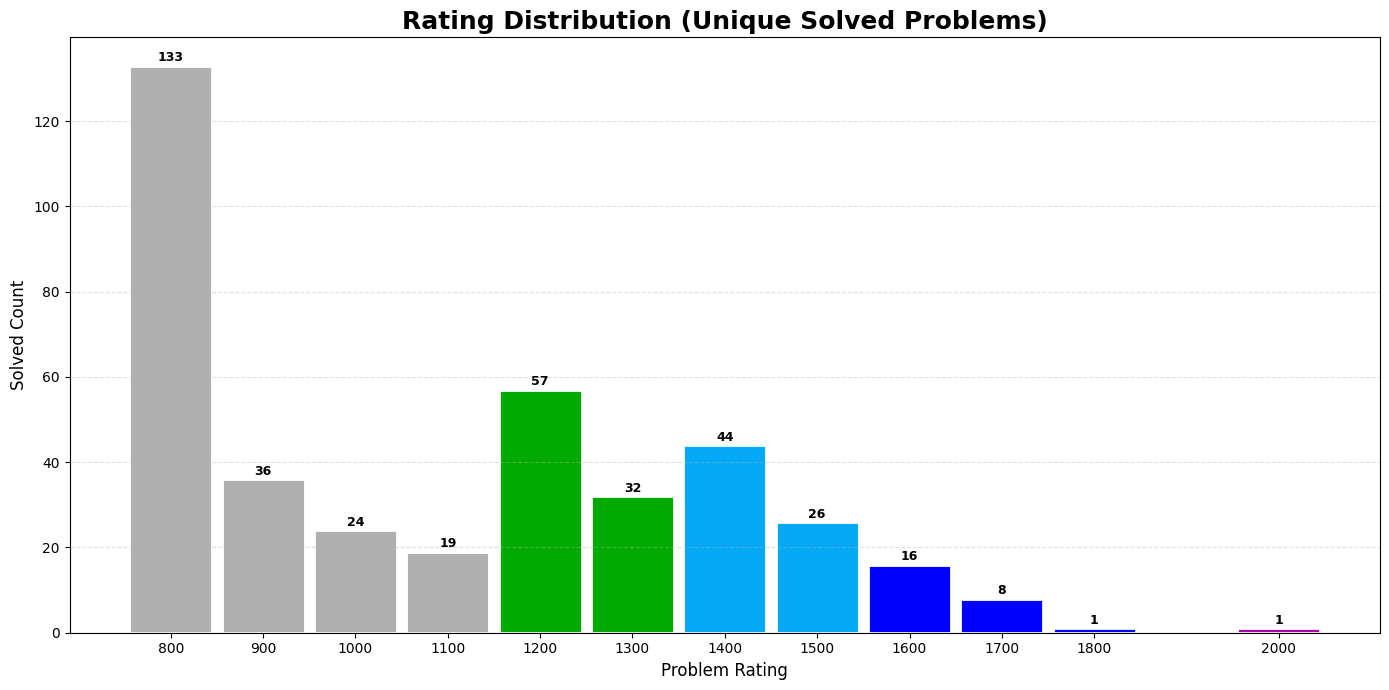

In [25]:
analyzer = RatingDistributionAnalyzer(
    solved_df
)

metrics = analyzer.calculate_metrics()

distribution = analyzer.rating_distribution()

growth_barrier = analyzer.detect_growth_barrier()

insights = analyzer.generate_insights()

print(metrics)

print()

print("Growth Barrier:", growth_barrier)

print()

for line in insights:
    print("•", line)

analyzer.plot_rating_distribution()

#Contest Analytics
1. Contest Summary Dashboard
2. Rating Progression Analysis
3. Consistency Score
4. Momentum Score
5. Volatility Analysis
6. Contest Profile Generator


In [26]:
user['rating']

570

In [27]:
import requests
import pandas as pd

handle = "akashdwivedi1409"
url_contest_history = f"https://codeforces.com/api/user.rating?handle={handle}"
response_contest_history = requests.get(url_contest_history)
data_contest_history = response_contest_history.json()

if data_contest_history['status'] == 'OK':
    contest_records = data_contest_history['result']
    contest_df = pd.DataFrame(contest_records)
    contest_df['rating_change'] = contest_df['newRating'] - contest_df['oldRating']
else:
    print(f"Error fetching contest data: {data_contest_history.get('comment', 'Unknown error')}")
    contest_df = pd.DataFrame()

contest_df.head()

,contestId,contestName,handle,rank,ratingUpdateTimeSeconds,oldRating,newRating,rating_change
0,2127,"Atto Round 1 (Codeforces Round 1041, Div. 1 + ...",akashdwivedi1409,12076,1754588100,0,363,363
1,2131,Codeforces Round 1042 (Div. 3),akashdwivedi1409,21729,1754844600,363,593,230
2,2132,Codeforces Round 1043 (Div. 3),akashdwivedi1409,24516,1755795000,593,734,141
3,2137,Codeforces Round 1047 (Div. 3),akashdwivedi1409,21297,1757263800,734,771,37
4,2140,Codeforces Round 1049 (Div. 2),akashdwivedi1409,13327,1757435700,771,777,6


In [28]:
contest_df["rating_change"] = (
    contest_df["newRating"]
    - contest_df["oldRating"]
)

In [29]:
def contest_summary(contest_df):
    summary = {
        "total_contests": len(contest_df), "current_rating" : contest_df["newRating"].mean(),
        "max_rating": contest_df["newRating"].max(),
        "min_rating": contest_df["newRating"].min(),
        "best_rank" : contest_df["rank"].min(),
        "worst_rank" : contest_df["rank"].max(),
        "average_rating_change" : contest_df["rating_change"].mean(),
        "biggest_gain" : contest_df["rating_change"].max(),
        "biggest_loss" : contest_df["rating_change"].min()
    }

    return summary



In [30]:
import requests
import pandas as pd

handle = "akashdwivedi1409"
url_contest_history = f"https://codeforces.com/api/user.rating?handle={handle}"
response_contest_history = requests.get(url_contest_history)
data_contest_history = response_contest_history.json()

if data_contest_history['status'] == 'OK':
    contest_records = data_contest_history['result']
    contest_df = pd.DataFrame(contest_records)

    contest_df['rating_change'] = contest_df['newRating'] - contest_df['oldRating']
else:
    print(f"Error fetching contest data: {data_contest_history.get('comment', 'Unknown error')}")
    contest_df = pd.DataFrame()
if not contest_df.empty:
    summary = contest_summary(contest_df)
    print("Contest Summary")
    for key, value in summary.items():
        print(
        f"{key.replace('_',' ').title()} : {value}"
        )
else:
    print("No contest data available to generate summary.")

Contest Summary
Total Contests : 40
Current Rating : 728.075
Max Rating : 941
Min Rating : 363
Best Rank : 6669
Worst Rank : 24516
Average Rating Change : 14.25
Biggest Gain : 363
Biggest Loss : -90


2. Rating Progression Analysis

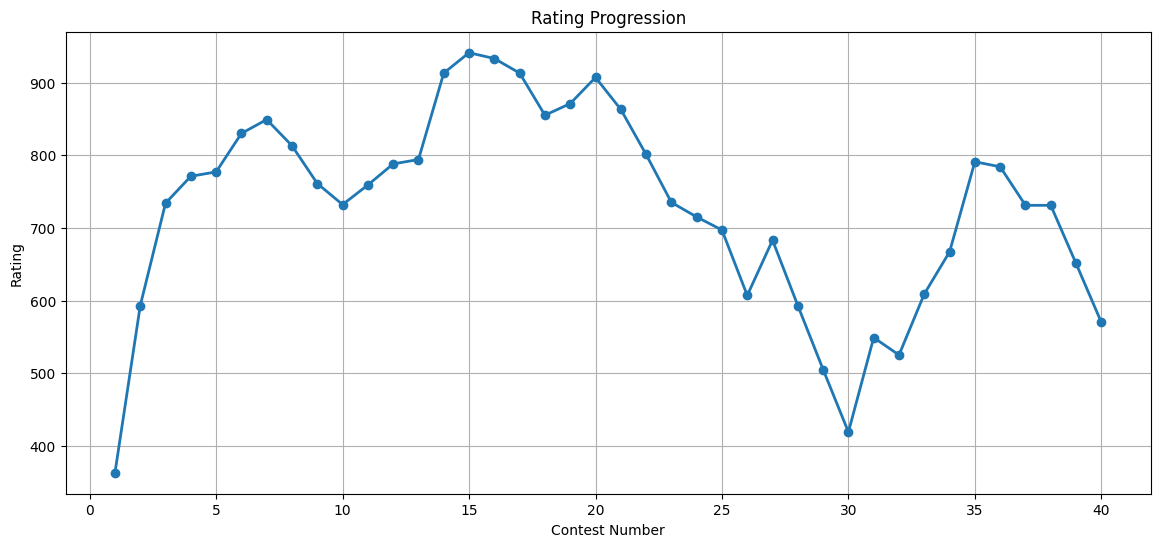

In [31]:


plt.figure(figsize=(14,6))

plt.plot(
    range(1, len(contest_df)+1),
    contest_df["newRating"],
    marker="o",
    linewidth=2
)

plt.xlabel("Contest Number")
plt.ylabel("Rating")

plt.title("Rating Progression")

plt.grid(True)

plt.show()

In [32]:
first_rating = contest_df["oldRating"].iloc[0]

current_rating = contest_df["newRating"].iloc[-1]

total_contests = len(contest_df)

growth_rate = (
    current_rating - first_rating
) / total_contests

print(
    f"Growth Rate: {growth_rate:.2f} rating/contest"
)

Growth Rate: 14.25 rating/contest


In [33]:
changes = contest_df["rating_change"]

current = 0
best = 0

for change in changes:

    if change > 0:
        current += 1
        best = max(best, current)
    else:
        current = 0

print(
    f"Longest Growth Streak: {best} contests"
)

Longest Growth Streak: 7 contests


In [34]:
current = 0
worst = 0

for change in changes:

    if change < 0:
        current += 1
        worst = max(worst, current)
    else:
        current = 0

print(
    f"Longest Decline Streak: {worst} contests"
)

Longest Decline Streak: 6 contests


In [35]:
recoveries = 0
drops = 0

changes = contest_df["rating_change"].tolist()

for i in range(len(changes)-1):

    if changes[i] < 0:

        drops += 1

        if changes[i+1] > 0:
            recoveries += 1

if drops > 0:

    recovery_rate = (
        recoveries / drops
    ) * 100

else:

    recovery_rate = 0

print(
    f"Recovery Rate: {recovery_rate:.1f}%"
)

Recovery Rate: 26.3%


In [36]:
print(" RATING PROGRESSION ANAYSIS")

print(
    f"Growth Rate : {growth_rate:.2f} rating/contest"
)

print(
    f"Longest Growth Streak : {best}"
)

print(
    f"Longest Decline Streak : {worst}"
)

print(
    f"Recovery Rate : {recovery_rate:.1f}%"
    #after a bad contest(rating drop) how often do you bounce back in the very next contest
)

 RATING PROGRESSION ANAYSIS
Growth Rate : 14.25 rating/contest
Longest Growth Streak : 7
Longest Decline Streak : 6
Recovery Rate : 26.3%


3,4,5. Consistency Score + Volatility Analysis

In [37]:
changes = contest_df["rating_change"]

In [38]:
volatility = np.std(changes)
print(f"Volatility Index: {volatility:.2f}")
#how bad the player is means when the player keep performing bad in the contest his volatility would be very high

Volatility Index: 91.49


In [39]:
#Consistency Score
consistency_score = max(0, 100 - (volatility))
print(f"Consistency Score: {consistency_score:.2f}/100")
#

Consistency Score: 8.51/100


In [40]:
#Classification of the user
if consistency_score >= 80 :
  consistency_lebel = "Highly Consistent"

elif consistency_score >= 60 :
  consistency_lebel = "Moderately Consistent"
elif consistency_score >= 40 :
  consistency_lebel = "Slightly Consistent"
else:
  consistency_lebel = "Highly Volatile"

print(f"Consistency Label: {consistency_lebel}")

Consistency Label: Highly Volatile


In [41]:
#positive and the negative contest
positive_contests = (contest_df["rating_change"] > 0).sum()
negative_contests = (contest_df["rating_change"] < 0).sum()
neutral_contests = (contest_df["rating_change"] == 0).sum()

In [42]:
total = len(contest_df)
positive_pct = (positive_contests / total) * 100
negative_pct = (negative_contests / total) * 100
neutral_pct = (neutral_contests / total) * 100

In [43]:
win_rate = positive_pct


In [44]:

print("\n CONSISTENCY ANALYSIS\n")

print(
    f"Volatility Index : {volatility:.2f}"
)

print(
    f"Consistency Score : {consistency_score:.2f}/100"
)

print(
    f"Profile : {consistency_lebel}"
)

print()

print(
    f"Positive Contests : {positive_pct:.1f}%"
)

print(
    f"Negative Contests : {negative_pct:.1f}%"
)

print(
    f"Neutral Contests : {neutral_pct:.1f}%"
)



 CONSISTENCY ANALYSIS

Volatility Index : 91.49
Consistency Score : 8.51/100
Profile : Highly Volatile

Positive Contests : 47.5%
Negative Contests : 50.0%
Neutral Contests : 2.5%


##4. Momentum Score

In [48]:
changes = contest_df["rating_change"]

last_5_avg = changes.tail(5).mean()
last_10_avg = changes.tail(10).mean()
overall_avg = changes.mean()

if last_5_avg > overall_avg + 20:
    momentum = "Strong Uptrend"

elif last_5_avg > overall_avg:
    momentum = "Improving"

elif last_5_avg > overall_avg - 20:
    momentum = "Stable"

else:
    momentum = "Temporary Slump"

trend_strength = last_5_avg - overall_avg

print(f"Trend Strength: {trend_strength:.2f}")



print("MOMENTUM ANALYSIS")

print(f"Last 5 Avg Gain  : {last_5_avg:.2f}")
print(f"Last 10 Avg Gain : {last_10_avg:.2f}")
print(f"Overall Avg Gain : {overall_avg:.2f}")

print(f"\nMomentum Status : {momentum}")

print(
    f"Trend Strength : {trend_strength:.2f}"
)

Trend Strength: -58.45
MOMENTUM ANALYSIS
Last 5 Avg Gain  : -44.20
Last 10 Avg Gain : 15.10
Overall Avg Gain : 14.25

Momentum Status : Temporary Slump
Trend Strength : -58.45


5.Volatility Anaylsis


In [49]:
best_contest = contest_df.loc[
    contest_df["rating_change"].idxmax()
]

print("BEST CONTEST")

print(
    f"Contest: {best_contest['contestName']}"
)

print(
    f"Rank: {best_contest['rank']}"
)

print(
    f"Rating Change: +{best_contest['rating_change']}"
)

BEST CONTEST
Contest: Atto Round 1 (Codeforces Round 1041, Div. 1 + Div. 2)
Rank: 12076
Rating Change: +363


In [50]:
worst_contest = contest_df.loc[
    contest_df["rating_change"].idxmin()
]

print("WORST CONTEST")

print(
    f"Contest: {worst_contest['contestName']}"
)

print(
    f"Rank: {worst_contest['rank']}"
)

print(
    f"Rating Change: {worst_contest['rating_change']}"
)

WORST CONTEST
Contest: Codeforces Round 1075 (Div. 2)
Rank: 15957
Rating Change: -90


In [51]:
window = 5

changes = contest_df[
    "rating_change"
].tolist()

best_gain = -float("inf")
best_start = 0

for i in range(
    len(changes)-window+1
):

    gain = sum(
        changes[i:i+window]
    )

    if gain > best_gain:

        best_gain = gain
        best_start = i

In [52]:
print("PEAK GROWTH PERIOD")

print(
    f"Contest Range: "
    f"{best_start+1}"
    f" - "
    f"{best_start+window}"
)

print(
    f"Total Rating Gain: "
    f"{best_gain}"
)

PEAK GROWTH PERIOD
Contest Range: 1 - 5
Total Rating Gain: 777


In [53]:
worst_gain = float("inf")
worst_start = 0

for i in range(
    len(changes)-window+1
):

    gain = sum(
        changes[i:i+window]
    )

    if gain < worst_gain:

        worst_gain = gain
        worst_start = i

In [54]:
print("WORST SLUMP")

print(
    f"Contest Range: "
    f"{worst_start+1}"
    f" - "
    f"{worst_start+window}"
)

print(
    f"Total Rating Change: "
    f"{worst_gain}"
)

WORST SLUMP
Contest Range: 26 - 30
Total Rating Change: -278


In [56]:
#Breakthrough Contest Detection
import numpy as np
mean_change = np.mean(changes)
std_change = np.std(changes)

breakthroughs = contest_df[
    contest_df["rating_change"]
    >
    mean_change + std_change
]

print("BREAKTHROUGH CONTESTS")

for _, row in breakthroughs.iterrows():
    print(
        f"{row['contestName']} "
        f"(+{row['rating_change']})"

    )

BREAKTHROUGH CONTESTS
Atto Round 1 (Codeforces Round 1041, Div. 1 + Div. 2) (+363)
Codeforces Round 1042 (Div. 3) (+230)
Codeforces Round 1043 (Div. 3) (+141)
Codeforces Global Round 30 (Div. 1 + Div. 2) (+119)
Educational Codeforces Round 187 (Rated for Div. 2) (+130)
Codeforces Round 1090 (Div. 4) (+124)


In [58]:
#Contest where the user collapased

collapses = contest_df[
    contest_df["rating_change"]
    <
    mean_change - std_change
]

print("COLLAPSE CONTESTS")

for _, row in collapses.iterrows():
    print(
        f"{row['contestName']} "
        f"({row['rating_change']})"
    )


COLLAPSE CONTESTS
Codeforces Round 1075 (Div. 2) (-90)
Codeforces Round 1077 (Div. 2) (-90)
Codeforces Round 1081 (Div. 2) (-88)
Codeforces Round 1082 (Div. 2) (-86)
Spectral::Cup 2026 Round 1 (Codeforces Round 1094, Div. 1 + Div. 2) (-80)
Codeforces Round 1095 (Div. 2) (-81)


##6.Contest Profile Generator

In [62]:
if growth_rate > 20:
    growth_profile = "Explosive Growth"

elif growth_rate > 10:
    growth_profile = "Rapid Improver"

elif growth_rate > 0:
    growth_profile = "Steady Improver"

else:
    growth_profile = "Stagnating"


if volatility < 30:
    consistency_profile = "Highly Consistent"

elif volatility < 60:
    consistency_profile = "Moderately Consistent"

else:
    consistency_profile = "Highly Volatile"



momentum_profile = momentum #momentum status you have already generated

contests = len(contest_df)

if contests > 100 :
  activity_profile = "Highly Active"

elif contests > 50 :
  activity_profile = "Active"


elif contests > 20 :
  activity_profile = "Moderate Active"

else:
  activity_profile = "Low Activity"





if (
    growth_rate > 10
    and momentum != "Sharp Decline"
):

    growth_potential = "High"

elif growth_rate > 0:

    growth_potential = "Medium"

else:

    growth_potential = "Low"



if (
    growth_rate > 10
    and momentum == "Strong Uptrend"
):
    archetype = "Aggressive Climber"

elif (
    growth_rate > 5
    and momentum in ["Improving", "Stable"]
):
    archetype = "Consistent Improver"

elif (
    momentum == "Temporary Slump"
    and growth_rate > 0
):
    archetype = "Recovering Competitor"

elif (
    growth_rate <= 0
    and momentum == "Temporary Slump"
):
    archetype = "Struggling Competitor"

elif (
    volatility > 80
):
    archetype = "Unpredictable Competitor"

else:
    archetype = "Stable Performer"


In [63]:
#Coaching Recommendation
if momentum == "Temporary Slump":

    recommendation = (
        "Focus on contest practice "
        "and post-contest upsolving."
    )

elif volatility > 60:

    recommendation = (
        "Reduce performance swings "
        "through regular participation."
    )

else:

    recommendation = (
        "Continue current growth strategy."
    )

In [65]:
#final profile
print("        CONTEST PROFILE")

print(f"Player Type        : {archetype}")

print(f"Growth Profile     : {growth_profile}")

print(f"Consistency        : {consistency_profile}")

print(f"Momentum           : {momentum_profile}")

print(f"Activity Level     : {activity_profile}")

print(f"Growth Potential   : {growth_potential}")

print()

print("Coach Recommendation:")

print(recommendation)

        CONTEST PROFILE
Player Type        : Recovering Competitor
Growth Profile     : Rapid Improver
Consistency        : Highly Volatile
Momentum           : Temporary Slump
Activity Level     : Moderate Active
Growth Potential   : High

Coach Recommendation:
Focus on contest practice and post-contest upsolving.


#Phase 3 -> Recommendation Engine